# Order Book Updates — Live Book Reconstruction

An order book is the outstanding bids and asks for a market, by price level. Coin Metrics serves it **three ways** — the three delivery schemas:

1. **Historical snapshots** — periodic point-in-time state of the whole book.
2. **Historical updates + snapshots** — the full event-driven stream of level changes; reconstruct the exact book at any timestamp (`dataset=updates`).
3. **Real-time streaming** — a live websocket that opens with a snapshot, then streams updates.

All three share **one** `[price, size]` message shape (a `size` of `0` removes a level), so the **same reconstruction code works across all of them**. This notebook is fully self-contained — every cell uses the Coin Metrics Python client directly — and it makes the point concrete by **streaming a live sample, then replaying the exact same time window from the historical `updates` dataset**.

## Setup

The only dependency is the Coin Metrics Python API client (`pip install coinmetrics-api-client`). The API key is read from the environment — never hardcode it.

In [1]:
import os, json, time
from datetime import timedelta
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display
from coinmetrics.api_client import CoinMetricsClient

client = CoinMetricsClient(os.environ["CM_API_KEY"])
MARKET = 'coinbase-btc-usd-spot'
DEPTH_PCT = 0.001   # depth band around the mid (0.001 = 0.1%)

## Schema 1 — Historical snapshots

The simplest shape: a periodic **snapshot** of the whole book. Coin Metrics stores three snapshot products — the top **100** levels and all levels **within 10% of mid** every **10s**, and the **full book hourly**. We pull the latest few (top-100) and show the top of the most recent one:

In [2]:
# Latest few snapshots (default "snapshots" dataset), returned as a DataFrame.
# limit_per_market + paging_from use format="json" (json_stream always streams from start).
snaps = client.get_market_orderbooks(
    markets=[MARKET],
    limit_per_market=3,
    depth_limit="100",
    paging_from="end",
    format="json",
).to_dataframe()

latest = snaps.sort_values("time").iloc[-1]   # most recent snapshot
print(f"latest snapshot: {latest['time']}")
pd.DataFrame({
    "bid_price": [l["price"] for l in latest["bids"][:5]],
    "bid_size":  [l["size"]  for l in latest["bids"][:5]],
    "ask_price": [l["price"] for l in latest["asks"][:5]],
    "ask_size":  [l["size"]  for l in latest["asks"][:5]],
})

latest snapshot: 2026-07-07 05:31:59.984346+00:00


,bid_price,bid_size,ask_price,ask_size
0,63033.89,0.36320277,63033.9,0.09268223
1,63033.88,0.03,63035.48,0.05552568
2,63033.86,0.03,63036.42,0.00022309
3,63033.8,0.00079322,63037.05,0.01784664
4,63032.01,0.11820631,63037.61,0.0694071


## Reconstructing the book

Both the update stream and the websocket deliver the same messages: a `snapshot` is the full state; an `update` carries absolute `[price, size]` levels where a `size` of `0` removes the level. To maintain the book, treat **every** `snapshot` as a full reset (a redundant-stream failover can emit an out-of-band snapshot), then apply updates in time order. That's the whole algorithm:

In [3]:
def new_book():
    return {"bids": {}, "asks": {}}   # price -> size, per side

def apply_message(book, msg):
    if msg.get("type") == "snapshot":       # full state replacement
        book["bids"].clear()
        book["asks"].clear()
    for side in ("bids", "asks"):           # snapshot or update: apply levels
        levels = msg.get(side)
        if levels is None:
            continue
        for level in levels:
            price, size = float(level["price"]), float(level["size"])
            if size == 0:
                book[side].pop(price, None)  # level removed
            else:
                book[side][price] = size

def best_bid_ask(book):
    bid = max(book["bids"]) if book["bids"] else None
    ask = min(book["asks"]) if book["asks"] else None
    return bid, ask

And a small helper to **animate** the top of the book as messages are applied. The *same* function works on live websocket messages and on historical `updates` rows — because they are the same message shape. Levels are drawn by rank (best bid/ask at the center, deeper levels outward) so the bars stay readable and never overlap:

In [4]:
GREEN, CORAL, DARK, TEXT, MUTED = "#22CAAD", "#F96167", "#10121A", "#C9D2DC", "#8E97A8"

def animate_book(messages, out_path, title, top_n=12, max_frames=100, fps=12):
    book, frames = new_book(), []
    for msg in messages:
        apply_message(book, msg)
        if not book["bids"] or not book["asks"]:
            continue
        bids = sorted(book["bids"], reverse=True)[:top_n]
        asks = sorted(book["asks"])[:top_n]
        frames.append(([(p, book["bids"][p]) for p in bids],
                       [(p, book["asks"][p]) for p in asks]))
    if len(frames) > max_frames:
        frames = frames[:: max(1, len(frames) // max_frames)]

    ymax = max((s for b, a in frames for _, s in b + a), default=1.0) * 1.1
    fig, ax = plt.subplots(figsize=(7, 4))
    fig.patch.set_facecolor(DARK)

    def draw(i):
        ax.clear(); ax.set_facecolor(DARK)
        bids, asks = frames[i]
        ax.bar([-(j + 0.5) for j in range(len(bids))], [s for _, s in bids], width=0.9, color=GREEN)
        ax.bar([(j + 0.5) for j in range(len(asks))], [s for _, s in asks], width=0.9, color=CORAL)
        ax.axvline(0, color=MUTED, ls="--", lw=0.8, alpha=0.6)
        ax.text(-0.5, ymax * 0.99, f"bid {bids[0][0]:,.2f}", color=GREEN, fontsize=7.5, ha="right", va="top")
        ax.text(0.5, ymax * 0.99, f"ask {asks[0][0]:,.2f}", color=CORAL, fontsize=7.5, ha="left", va="top")
        ax.text(-(len(bids) - 0.5), ymax * 0.88, f"{bids[-1][0]:,.2f}", color=MUTED, fontsize=6, ha="center", va="top")
        ax.text((len(asks) - 0.5), ymax * 0.88, f"{asks[-1][0]:,.2f}", color=MUTED, fontsize=6, ha="center", va="top")
        ax.set_xlim(-(top_n + 0.5), top_n + 0.5); ax.set_ylim(0, ymax); ax.set_xticks([])
        ax.set_title(f"{title} · frame {i + 1}/{len(frames)}", color=TEXT, fontsize=10)
        ax.set_xlabel("best bid/ask at center · deeper levels outward   (bids ←  |  → asks)", color=TEXT, fontsize=8)
        ax.set_ylabel("size", color=TEXT, fontsize=8)
        ax.tick_params(colors=TEXT, labelsize=7)
        for sp in ("top", "right"): ax.spines[sp].set_visible(False)
        for sp in ("left", "bottom"): ax.spines[sp].set_color(MUTED)

    anim = FuncAnimation(fig, draw, frames=len(frames), interval=1000 / fps)
    anim.save(out_path, writer=PillowWriter(fps=fps), savefig_kwargs={"facecolor": DARK})
    plt.close(fig)
    return out_path

## Schema 3 — Real-time streaming

The websocket feed opens with a `snapshot`, then sends `update` messages as the book changes (with occasional re-sync snapshots) — **the production path** for a live book. We subscribe at **`depth_limit="full_book"`** (the stream defaults to top-100) so the live feed matches the historical `updates` dataset, which is full-book — making the two directly comparable. We take a small live sample and **record the time window it spans**, so we can replay exactly that window from history next.

> This cell is *live*: its exact messages (and window) differ every run — unlike the historical replay below, which is reproducible.

In [5]:
def stream_sample(market, n, max_seconds=120):
    """Consume `n` websocket messages, then close. Full-book to match the updates dataset."""
    stream = client.get_stream_market_orderbooks(markets=[market], depth_limit="full_book")
    messages = []
    start = time.time()
    def on_message(ws, message):
        messages.append(json.loads(message))
        if len(messages) >= n or time.time() - start > max_seconds:
            ws.close()
    stream.run(on_message=on_message, reconnect=False)
    return messages

live_msgs = stream_sample(MARKET, n=800)
times = sorted(m["time"] for m in live_msgs)
# The window we just watched, truncated to whole seconds (the messages carry
# nanosecond timestamps; .parallel() chunking needs a second-precision start/end).
win_start, win_end = times[0][:19] + "Z", times[-1][:19] + "Z"
live_changes = sum(len(m.get("asks") or []) + len(m.get("bids") or []) for m in live_msgs)
print(f"{len(live_msgs):,} live messages, {live_changes:,} level-changes")
print(f"streamed window: {win_start} -> {win_end}")
live_msgs[0]

800 live messages, 85,120 level-changes
streamed window: 2026-07-07T05:31:59Z -> 2026-07-07T05:32:12Z


{'market': 'coinbase-btc-usd-spot',
 'time': '2026-07-07T05:31:59.984346000Z',
 'coin_metrics_id': 'FxT65kMNSy6PL0celq9B7AAAAACEbj6G',
 'asks': [{'price': '63033.9', 'size': '0.09268223'},
  {'price': '63035.48', 'size': '0.05552568'},
  {'price': '63036.42', 'size': '0.00022309'},
  {'price': '63037.05', 'size': '0.01784664'},
  {'price': '63037.61', 'size': '0.0694071'},
  {'price': '63038', 'size': '0.0815'},
  {'price': '63039.97', 'size': '0.00794908'},
  {'price': '63039.98', 'size': '0.02'},
  {'price': '63040', 'size': '0.0815'},
  {'price': '63041.11', 'size': '0.02'},
  {'price': '63041.12', 'size': '0.32528252'},
  {'price': '63041.13', 'size': '0.12690129'},
  {'price': '63041.98', 'size': '0.09541977'},
  {'price': '63041.99', 'size': '0.04781428'},
  {'price': '63042', 'size': '0.085718'},
  {'price': '63042.83', 'size': '0.000097'},
  {'price': '63043.97', 'size': '0.06345327'},
  {'price': '63043.99', 'size': '0.03975824'},
  {'price': '63044', 'size': '0.0857'},
  {'pr

Animate the live book as those messages are applied (green bids, coral asks):

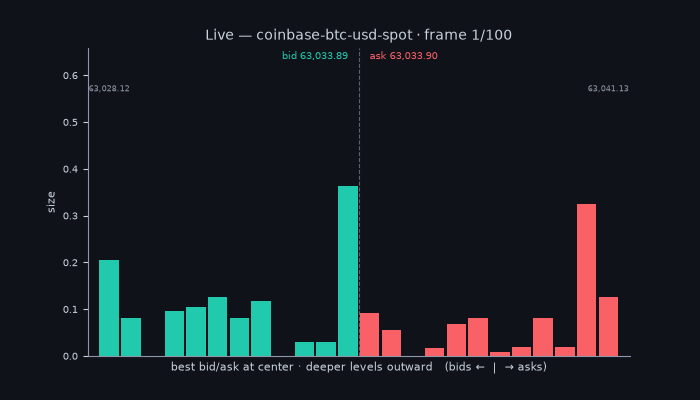

In [6]:
display(Image(animate_book(live_msgs, "live_book.gif", f"Live — {MARKET}")))

## Schema 2 — Historical updates + snapshots (replay the window we just streamed)

`dataset=updates` returns the **identical** message shape (snapshot + updates) for a **historical** window, and the sequence is **reproducible** — the same market and time range return the same rows on every query. Instead of a hard-coded window, we pass the **`win_start` / `win_end` we just captured from the live stream** — so we replay the very window we watched live. Following the product docs, we fetch it **in parallel** and return a **DataFrame** (`.parallel(time_increment=…).to_dataframe()`), then reconstruct with the **same `apply_message` / `animate_book`** code. `start_with_snapshot=True` prepends a snapshot so we can initialise before the first update.

> **Row count vs live-message count.** Both feeds carry the **full book** (we subscribed the websocket at `depth_limit="full_book"` to match). The websocket **bundles many level changes into each message**, while historical `granularity="raw"` emits them as **finer, individual rows** — so there are more rows than live messages, but the **total book activity (level-changes) is comparable**. Same book, same schema, same code — just different message framing.

> Historical updates settle after a short persistence lag, so the final seconds of a just-streamed window may still be landing; the leading snapshot keeps the replay well-formed regardless.

In [7]:
df = client.get_market_orderbooks(
    markets=[MARKET],
    dataset="updates",
    start_with_snapshot=True,   # leading snapshot to initialise the book
    depth_limit="full_book",
    granularity="raw",
    format="json_stream",
    paging_from="start",
    start_time=win_start,       # the window we streamed live above
    end_time=win_end,
).parallel(time_increment=timedelta(minutes=1)).to_dataframe()

rows = df.to_dict("records")   # message dicts for reconstruction / animation
hist_changes = int(df["asks"].map(len).sum() + df["bids"].map(len).sum())
print(f"historical (raw): {len(df):,} rows, {hist_changes:,} level-changes")
print(f"live (websocket): {len(live_msgs):,} messages, {live_changes:,} level-changes")
df.head()

Exporting to dataframe type:   0%|          | 0/1 [00:00<?, ?it/s]

Exporting to dataframe type: 100%|██████████| 1/1 [00:08<00:00,  8.02s/it]

Exporting to dataframe type: 100%|██████████| 1/1 [00:08<00:00,  8.02s/it]

historical (raw): 52,974 rows, 97,459 level-changes
live (websocket): 800 messages, 85,120 level-changes


,market,time,coin_metrics_id,asks,bids,type,database_time,collect_time
0,coinbase-btc-usd-spot,2026-07-07 05:30:09.985257+00:00,AAEDAAZV_q83wulCVEMtVVNE,"[{'price': '62893.29', 'size': '0.00141817'}, ...","[{'price': '62893.28', 'size': '1.40248756'}, ...",snapshot,2026-07-07 05:30:10.204346194+00:00,2026-07-07 05:30:09.999438+00:00
1,coinbase-btc-usd-spot,2026-07-07 05:30:10.013888+00:00,AAEDAAZV_q84MsBCVEMtVVNE,[],"[{'price': '62871.98', 'size': '0.540278'}]",update,2026-07-07 05:30:10.204398185+00:00,2026-07-07 05:30:10.018256+00:00
2,coinbase-btc-usd-spot,2026-07-07 05:30:10.016763+00:00,AAEDAAZV_q84PftCVEMtVVNE,[],"[{'price': '62872.11', 'size': '0.48858106'}]",update,2026-07-07 05:30:10.204419996+00:00,2026-07-07 05:30:10.024894+00:00
3,coinbase-btc-usd-spot,2026-07-07 05:30:10.016875+00:00,AAEDAAZV_q84PmtCVEMtVVNE,"[{'price': '62925.66', 'size': '0.94122215'}, ...",[],update,2026-07-07 05:30:10.204430666+00:00,2026-07-07 05:30:10.024923+00:00
4,coinbase-btc-usd-spot,2026-07-07 05:30:10.018792+00:00,AAEDAAZV_q84RehCVEMtVVNE,"[{'price': '62925.67', 'size': '0'}]",[],update,2026-07-07 05:30:10.204440166+00:00,2026-07-07 05:30:10.024948+00:00


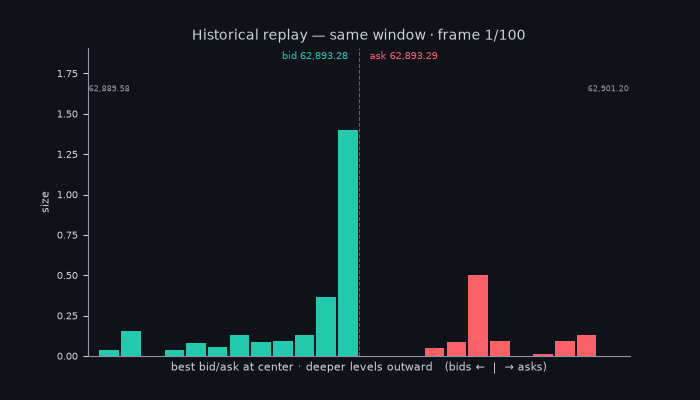

In [8]:
display(Image(animate_book(rows[:600], "historical_book.gif", "Historical replay — same window")))

## Reconstruct & measure

Replaying the updates in time order gives the level-1 series (best bid/ask, spread) and depth near the mid — the raw material for TCA, event studies, and backtests. The **same** `apply_message` that drove the animations builds the metrics here:

In [9]:
book, series = new_book(), []
for row in sorted(rows, key=lambda r: r["time"]):
    apply_message(book, row)
    bid, ask = best_bid_ask(book)
    if bid is None or ask is None:
        continue
    mid = (bid + ask) / 2
    lo, hi = mid * (1 - DEPTH_PCT), mid * (1 + DEPTH_PCT)
    series.append({
        "time": row["time"],
        "spread_bps": (ask - bid) / mid * 1e4,
        "bid_depth": sum(s for p, s in book["bids"].items() if p >= lo),
        "ask_depth": sum(s for p, s in book["asks"].items() if p <= hi),
    })

metrics = pd.DataFrame(series)
metrics["time"] = pd.to_datetime(metrics["time"])
metrics[["spread_bps", "bid_depth", "ask_depth"]].describe()

,spread_bps,bid_depth,ask_depth
count,52974.000000,52974.000000,52974.000000
mean,0.037895,13.749850,14.006826
std,0.110120,2.348151,2.138078
min,0.001587,6.192858,7.618362
25%,0.001588,12.175648,12.528570
50%,0.001589,13.971209,14.032747
75%,0.001590,15.600170,15.622603
max,1.188795,20.020468,22.517797


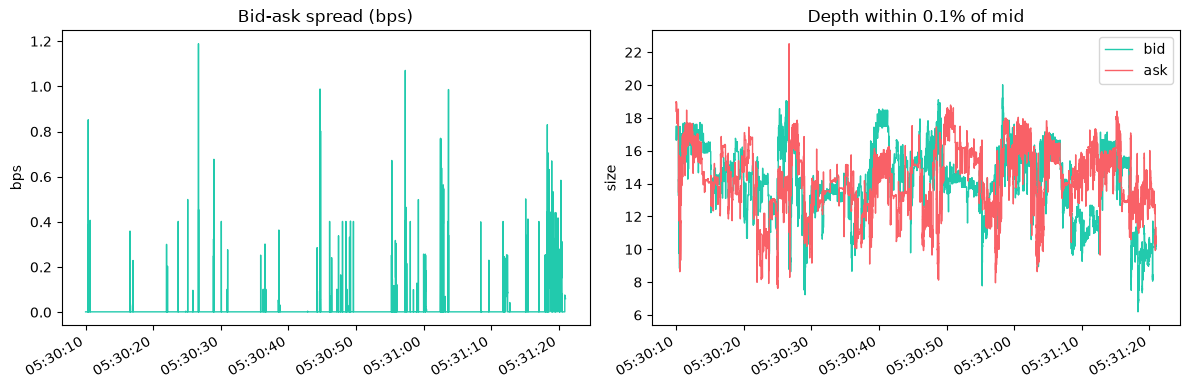

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(metrics["time"], metrics["spread_bps"], color=GREEN, lw=1)
ax1.set_title("Bid-ask spread (bps)"); ax1.set_ylabel("bps")
ax2.plot(metrics["time"], metrics["bid_depth"], color=GREEN, lw=1, label="bid")
ax2.plot(metrics["time"], metrics["ask_depth"], color=CORAL, lw=1, label="ask")
ax2.set_title(f"Depth within {DEPTH_PCT * 100:g}% of mid"); ax2.set_ylabel("size"); ax2.legend()
fig.autofmt_xdate()
plt.tight_layout(); plt.show()

## Takeaways

- **Three schemas, one data model.** Historical snapshots, historical updates, and the real-time stream all share the same `[price, size]` message shape.
- **One code path, live or historical.** The same `apply_message` reconstructs the book from websocket messages and from `dataset=updates` rows — we even replayed the exact window we had just streamed live.
- Treat **every** `snapshot` as a full reset (not just the first) — a redundant-stream failover can emit an out-of-band snapshot.
- Historical `dataset=updates` is **reproducible**, so research and production share the exact same book-building logic.